In [1]:
import numpy as np

scalar

In [4]:
np.random.seed(23)

vec1 = np.random.random(5)
vec2 = np.random.random(5)

vec1 = vec1 / vec1.sum()
vec2 = vec2 / vec2.sum()

np.sum(vec1 * np.log(vec1 / vec2))

np.float64(0.42014931773906783)

In [12]:
matrix1

array([[0.62673568, 0.17549672, 0.08096605, 0.31370103, 0.41412367],
       [0.39479186, 0.72304053, 0.51162474, 0.34364563, 0.46890828],
       [0.54673877, 0.83487472, 0.3480919 , 0.78318606, 0.65101143],
       [0.87302576, 0.41065096, 0.18415932, 0.09317831, 0.55735915],
       [0.97683169, 0.29572215, 0.39315909, 0.81879889, 0.3940116 ],
       [0.89082512, 0.03012576, 0.89981175, 0.29110562, 0.98071185],
       [0.77260442, 0.8124435 , 0.47472116, 0.30248712, 0.32412355],
       [0.88646358, 0.42954226, 0.00307864, 0.61899674, 0.63841461],
       [0.60213382, 0.08489766, 0.18878963, 0.77308566, 0.59030399],
       [0.68603619, 0.07309111, 0.56146753, 0.25862951, 0.22118358]])

In [13]:
matrix1.sum(axis=1)

array([1.61102315, 2.44201104, 3.16390288, 2.11837351, 2.87852341,
       3.09258009, 2.68637974, 2.57649583, 2.23921077, 1.80040794])

In [ ]:
np.linalg.solve(cov,np.eye(2))

array([[1.00000000e+00, 0.00000000e+00],
       [2.12175956e-16, 1.00000000e+00]])

In [ ]:
def calculate_gaussian_multivariate_pdf(mu, cov, vec):
    k = len(mu)

    diff = vec - mu

    det_cov = np.linalg(cov)
    inv_cov = np.linalg.solve(cov)

    prob = (
        (2 * np.pi) ** (-k / 2)
        * np.power(np.linalg.det(cov), -0.5)
        * np.power(
            np.e,
            -1
            / 2
            * (vec - mu).reshape((1, -1))
            @ np.linalg.inv(cov)
            @ (vec - mu).reshape((-1, 1)),
        ).flatten()[0]
    )
    return float(prob)


In [14]:
matrix1 = np.random.random((10, 5))
matrix2 = np.random.random((10, 5))

matrix1 = matrix1 / matrix1.sum(axis=1, keepdims=True)
matrix2 = matrix2 / matrix2.sum(axis=1, keepdims=True)

np.mean(np.sum(matrix1 * np.log(matrix1 / matrix2), axis=1))

np.float64(0.43658718453646683)

In [61]:
%matplotlib inline
import matplotlib.pyplot as plt

In [75]:
cov = np.eye(2)
cov[0, 1] = 0.8
cov[1, 0] = 0.8
mu = np.zeros(2)
k = 2

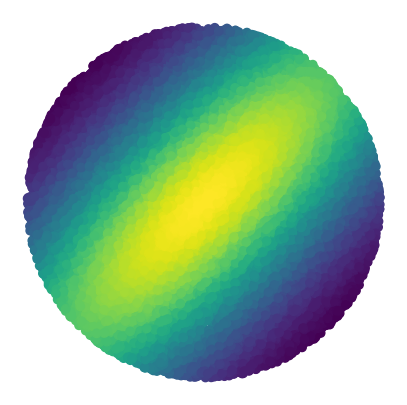

In [76]:
np.random.seed(23)
vecs, probs = [], []
for _ in range(20000):
    vec = (np.random.rand(2) - 0.5) * 2
    if np.linalg.norm(np.abs(vec), 2) >= 1:
        continue
    prob = calculate_gaussian_multivariate_pdf(mu, cov, vec)
    vecs.append(vec)
    probs.append(prob)

plt.figure(figsize=(5, 5))
x, y = np.array(vecs).T
plt.scatter(x, y, c=probs)
plt.axis("off")
plt.show()

In [31]:
(vec - mu).reshape((1, -1)) @ np.linalg.inv(cov) @ (vec - mu).reshape((-1, 1))

array([[0.71428571]])

In [32]:
((vec - mu).reshape((1, -1)) @ np.linalg.inv(cov)).shape

(1, 2)